# 01 — Study Area and Data Overview

South Kalimantan, Indonesia: health facilities, road network, population, and administrative boundaries used throughout this analysis. See `../PROTOCOL.md` for the full data-source rationale and `../docs/manuscript.md` for the write-up.

In [1]:
import geopandas as gpd
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

DATA_RAW = Path('../data/raw')
DATA_PROC = Path('../data/processed')

## Administrative boundaries

Province outline plus all 13 kabupaten/kota, colored by the district-capacity classification computed in notebook 04.

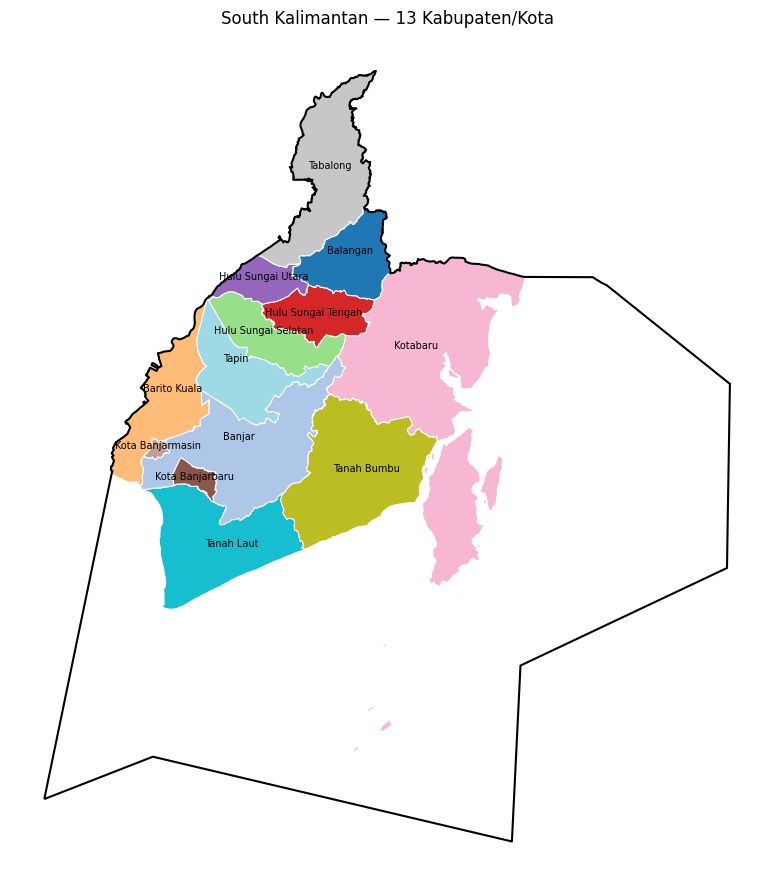

In [2]:
province = gpd.read_file(DATA_RAW / 'kalsel_boundary.geojson')
kabupaten = gpd.read_file(DATA_RAW / 'kalsel_kabupaten_boundaries.geojson')

fig, ax = plt.subplots(figsize=(9, 9))
kabupaten.plot(ax=ax, column='kabupaten', cmap='tab20', edgecolor='white', linewidth=0.8, legend=False)
province.boundary.plot(ax=ax, color='black', linewidth=1.5)
for _, row in kabupaten.iterrows():
    c = row.geometry.representative_point()
    ax.annotate(row['kabupaten'], (c.x, c.y), fontsize=7, ha='center')
ax.set_title('South Kalimantan — 13 Kabupaten/Kota')
ax.set_axis_off()
plt.tight_layout()
plt.show()

## Health facilities

90 facilities extracted from OpenStreetMap (see `../PROTOCOL.md` §6 for why the extraction method changed from live Overpass queries to streaming `pyosmium` parsing of the Geofabrik PBF).

amenity
clinic      46
hospital    35
doctors      9
Name: count, dtype: int64


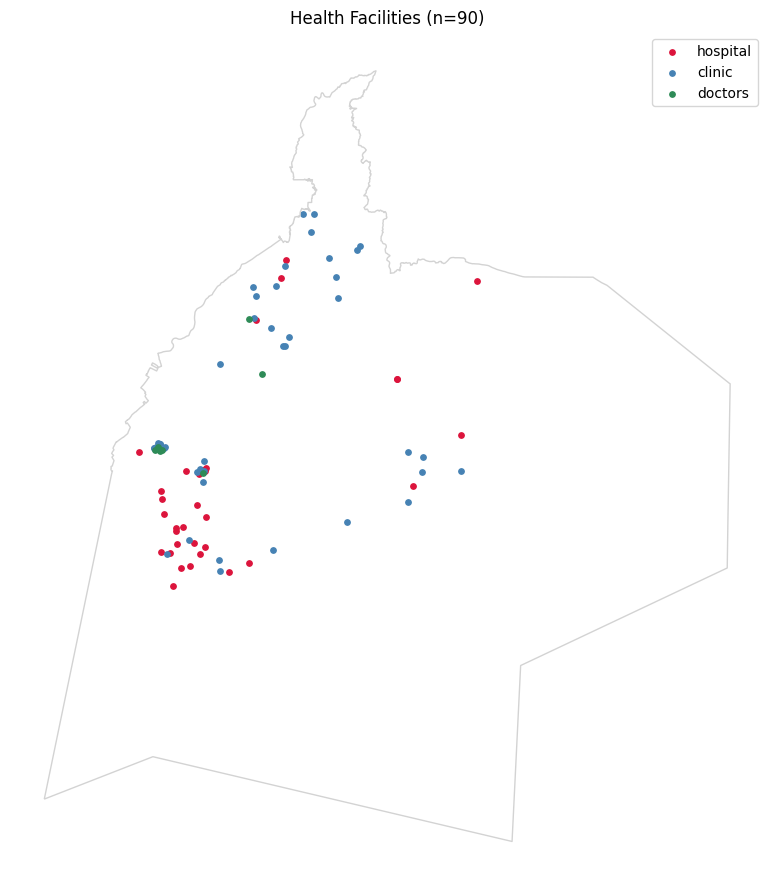

In [3]:
facilities = gpd.read_file(DATA_RAW / 'facilities' / 'kalsel_facilities.geojson')
print(facilities['amenity'].value_counts())

fig, ax = plt.subplots(figsize=(9, 9))
province.boundary.plot(ax=ax, color='lightgray', linewidth=1)
colors = {'hospital': 'crimson', 'clinic': 'steelblue', 'doctors': 'seagreen'}
for amenity, color in colors.items():
    sub = facilities[facilities['amenity'] == amenity]
    sub.plot(ax=ax, color=color, markersize=15, label=amenity)
ax.legend()
ax.set_title(f'Health Facilities (n={len(facilities)})')
ax.set_axis_off()
plt.tight_layout()
plt.show()

## Road network

62,674 classified road segments (motorway through residential; footway/path/track excluded), forming a 592k-node routable graph.

highway
residential       53780
unclassified       3384
tertiary           2500
trunk              1264
secondary           659
primary             635
trunk_link          251
tertiary_link        95
primary_link         66
secondary_link       40
Name: count, dtype: int64


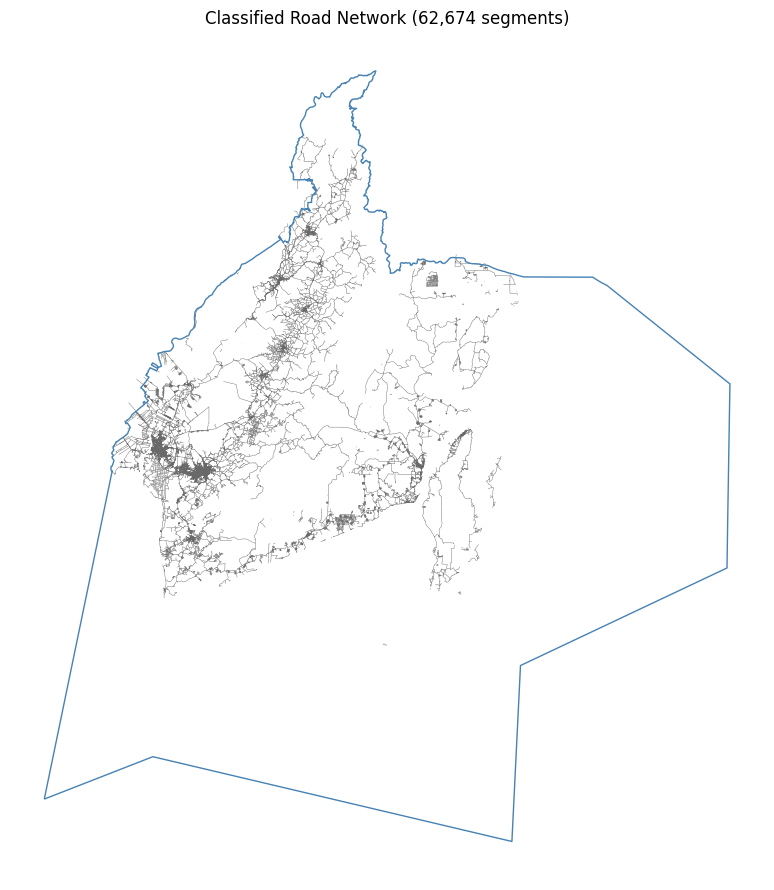

In [4]:
roads = gpd.read_file(DATA_RAW / 'population_roads' / 'kalsel_roads.geojson')
print(roads['highway'].value_counts())

fig, ax = plt.subplots(figsize=(9, 9))
roads.plot(ax=ax, linewidth=0.3, color='dimgray')
province.boundary.plot(ax=ax, color='steelblue', linewidth=1)
ax.set_title(f'Classified Road Network ({len(roads):,} segments)')
ax.set_axis_off()
plt.tight_layout()
plt.show()

## Population

WorldPop Indonesia 2020, clipped to the province.

C:\Users\miqba\AppData\Local\Temp\ipykernel_38192\2603613492.py:7: RuntimeWarning: invalid value encountered in log1p
  im = ax.imshow(np.log1p(pop_masked), extent=extent, cmap='inferno', origin='upper')


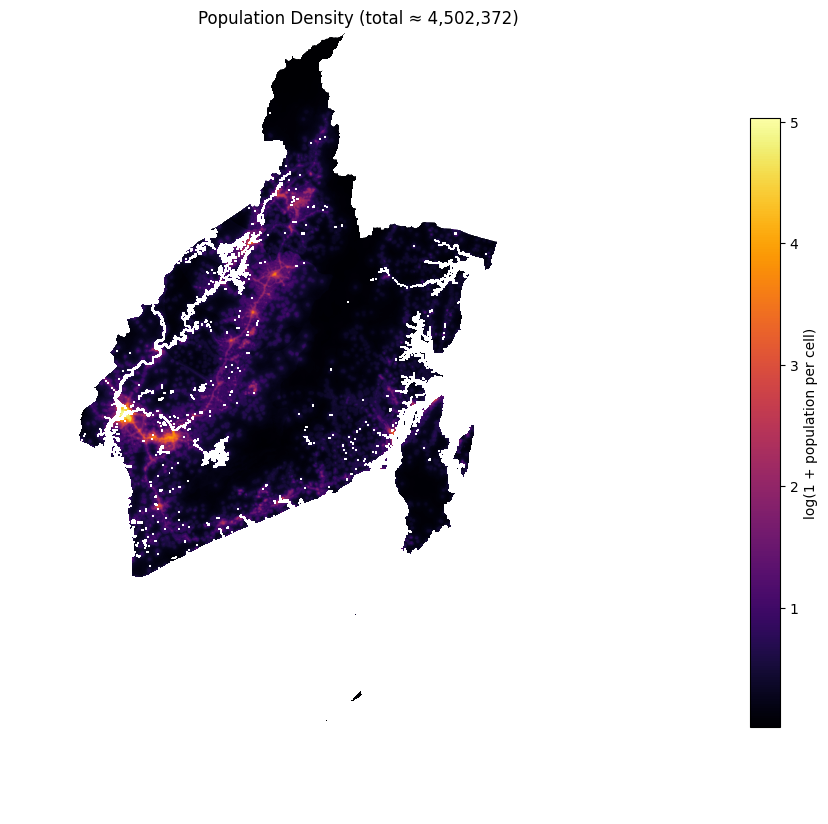

In [5]:
with rasterio.open(DATA_RAW / 'population_roads' / 'kalsel_population_2020.tif') as src:
    pop = src.read(1)
    pop_masked = np.ma.masked_less_equal(pop, 0)
    extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]

fig, ax = plt.subplots(figsize=(9, 9))
im = ax.imshow(np.log1p(pop_masked), extent=extent, cmap='inferno', origin='upper')
province.boundary.plot(ax=ax, color='white', linewidth=1)
plt.colorbar(im, ax=ax, label='log(1 + population per cell)', shrink=0.7)
ax.set_title(f'Population Density (total ≈ {np.nansum(pop_masked):,.0f})')
ax.set_axis_off()
plt.tight_layout()
plt.show()